Selecciona el archivo CSV (ej. Dataset_Bioinformatics.csv)


Saving Dataset_Bioinformatics_Completo.csv to Dataset_Bioinformatics_Completo.csv

TABLA 1: FLUJO DE DEPURACIÓN (ATTRITION TABLE)
                         Etapa del Proceso  Registros Restantes  Registros Eliminados
                     Fase 0: Carga Inicial                 3568                     0
         Fase 1: Duplicados Técnicos (<1h)                 3172                   396
     Fase 1.5: Eliminación Nulos (FIQ/WPI)                 3115                    57
       Fase 2: Consistencia Edad y Adultos                 3082                    33
Fase 3: Incongruencia Clínica y Flatliners                 2349                   733

TABLA 2: DISTRIBUCIÓN FINAL POR COHORTES
Cohort_Group  Pacientes_Unicos  Registros_Totales
     Group A               268                849
     Group B                97                215
     Group C               916               1285


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Generando visualización de validación...


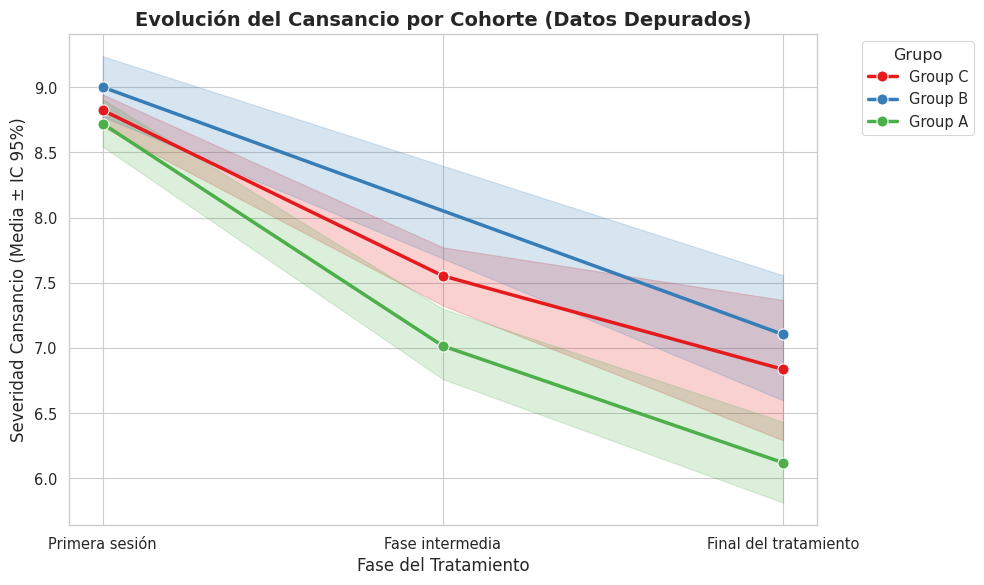


PROCESADO COMPLETADO: Dataset listo para análisis avanzado.


In [ ]:
import pandas as pd
import numpy as np
import os
from google.colab import files
import io
import warnings
import seaborn as sns
import matplotlib.pyplot as plt

# Configuración inicial
warnings.filterwarnings('ignore')

# =================================================================
# BLOQUE 1: CURACIÓN Y DEPURACIÓN DE DATOS (Data Curation)
# =================================================================

print("Selecciona el archivo CSV (ej. Dataset_Bioinformatics.csv)")
uploaded = files.upload()

if not uploaded:
    print("No se ha seleccionado ningún archivo.")
else:
    file_name = list(uploaded.keys())[0]
    # Carga con codificación estándar para datos españoles (latin-1 por las tildes)
    df_raw = pd.read_csv(io.BytesIO(uploaded[file_name]), sep=';', encoding='latin-1')

    # Métricas de control iniciales
    stats = []
    n_inicial = len(df_raw)
    stats.append(['Fase 0: Carga Inicial', n_inicial, 0])

    # Pre-procesamiento de Identificadores y Fechas
    df_raw['Edad'] = pd.to_numeric(df_raw['Edad'], errors='coerce')
    df_raw['UID'] = df_raw['Centro Médico'].astype(str) + "_" + df_raw['Número de Historia Clínica (IP Paciente)'].astype(str)
    df_raw['Marca temporal'] = pd.to_datetime(df_raw['Marca temporal'], format='mixed')
    df_raw['UID_Session'] = df_raw['UID'] + "_" + df_raw['Número de sesión']

    # --- FASE 1: DEPURACIÓN TÉCNICA (REGLA DE 1 HORA) ---
    def clean_duplicates(group):
        if len(group) == 1: return group
        diff_horas = (group['Marca temporal'].max() - group['Marca temporal'].min()).total_seconds() / 3600
        if diff_horas > 1: return pd.DataFrame()
        else: return group.sort_values('Marca temporal').tail(1)

    df_clean = df_raw.groupby('UID_Session', group_keys=False).apply(clean_duplicates)
    n_fase1 = len(df_clean)
    stats.append(['Fase 1: Duplicados Técnicos (<1h)', n_fase1, n_inicial - n_fase1])

    # --- FASE 1.5: LIMPIEZA DE NULOS CLÍNICOS (PREVENTIVA) ---
    # Paso crítico: Eliminar nulos antes de clasificar cohortes para evitar sesgos
    col_fiq = 'DIMENSION1_FIQ'
    col_wpi = 'WPI_TOTAL'
    col_cansancio = '¿Hasta qué punto se ha sentido cansado?'
    cols_funcionales = ['COMPRAR', 'LAVAR ', 'COMIDA', 'FREGAR ', 'ASPIRAR',
                         'CAMAS ', 'CAMINAR', 'AMIGOS', 'JARDIN', 'CONDUCIR', 'ESCALERAS']

    # Aseguramos formato numérico (punto decimal) y coercionamos errores a NaN
    for col in [col_fiq, col_wpi, col_cansancio] + cols_funcionales:
        if col in df_clean.columns:
            if df_clean[col].dtype == 'object':
                df_clean[col] = df_clean[col].str.replace(',', '.')
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

    # Eliminación de registros donde no hay datos esenciales para el análisis clínico
    df_clean = df_clean.dropna(subset=[col_fiq, col_wpi])
    n_fase1_5 = len(df_clean)
    stats.append(['Fase 1.5: Eliminación Nulos (FIQ/WPI)', n_fase1_5, n_fase1 - n_fase1_5])

    # --- FASE 2: ETIQUETADO Y CLASIFICACIÓN DE COHORTES ---
    # Se ejecuta después de limpiar nulos para que la clasificación sea real según datos disponibles
    def classify_cohort(sessions):
        s = set(sessions)
        if 'Primera sesión' in s and 'Fase intermedia' in s and 'Final del tratamiento' in s:
            return 'Group A'
        elif 'Primera sesión' in s and 'Final del tratamiento' in s:
            return 'Group B'
        return 'Group C'

    cohort_map = df_clean.groupby('UID')['Número de sesión'].apply(classify_cohort).reset_index()
    cohort_map.columns = ['UID', 'Cohort_Group']
    df_intermediate = pd.merge(df_clean, cohort_map, on='UID', how='left')

    # --- FASE 3: LIMPIEZA DIFERENCIAL DE EDAD ---
    def apply_age_validation(df_input):
        df_filtered = df_input.dropna(subset=['Edad'])
        df_filtered = df_filtered[(df_filtered['Edad'] >= 18) & (df_filtered['Edad'] < 100)].copy()

        final_uids = []
        for uid, group in df_filtered.groupby('UID'):
            cohort = group['Cohort_Group'].iloc[0]
            ages = group['Edad'].tolist()
            if cohort == 'Group A':
                consistent, selected_age = False, None
                if len(ages) >= 2:
                    for i in range(len(ages)):
                        for j in range(i + 1, len(ages)):
                            if abs(ages[i] - ages[j]) <= 2:
                                consistent, selected_age = True, (ages[i] + ages[j]) / 2
                                break
                        if consistent: break
                if consistent:
                    group = group.copy()
                    group['Edad'] = int(round(selected_age))
                    final_uids.append(group)
            else:
                if len(ages) == 1 or (max(ages) - min(ages)) <= 2:
                    group = group.copy()
                    group['Edad'] = int(round(np.mean(ages)))
                    final_uids.append(group)
        return pd.concat(final_uids).reset_index(drop=True) if final_uids else pd.DataFrame()

    df_age_cleaned = apply_age_validation(df_intermediate)
    n_fase3 = len(df_age_cleaned)
    stats.append(['Fase 2: Consistencia Edad y Adultos', n_fase3, n_fase1_5 - n_fase3])

    # --- FASE 4: FILTROS CLÍNICOS AVANZADOS (INCONGRUENCIAS Y FLATLINERS) ---
    uids_incongruentes = df_age_cleaned[(df_age_cleaned[col_fiq] >= 70) & (df_age_cleaned[col_wpi] <= 2)]['UID'].unique()
    uids_flat = df_age_cleaned[df_age_cleaned[cols_funcionales].std(axis=1) == 0]['UID'].unique()

    # Análisis de variabilidad en cansancio para pacientes con seguimiento largo
    var_c = df_age_cleaned[df_age_cleaned['Cohort_Group'] == 'Group A'].groupby('UID')[col_cansancio].std()
    uids_estaticos = var_c[var_c == 0].index.tolist()

    uids_excluir = set(uids_incongruentes) | set(uids_flat) | set(uids_estaticos)
    df_final_puro = df_age_cleaned[~df_age_cleaned['UID'].isin(uids_excluir)].copy()

    n_fase4 = len(df_final_puro)
    stats.append(['Fase 3: Incongruencia Clínica y Flatliners', n_fase4, n_fase3 - n_fase4])

    # --- 7. RESULTADOS FINALES Y EXPORTACIÓN ---
    df_stats = pd.DataFrame(stats, columns=['Etapa del Proceso', 'Registros Restantes', 'Registros Eliminados'])

    # Tabla de distribución por cohortes (Pacientes únicos vs Registros totales)
    df_dist = df_final_puro.groupby('Cohort_Group').agg(
        Pacientes_Unicos=('UID', 'nunique'),
        Registros_Totales=('UID', 'size')
    ).reset_index()

    print("\n" + "="*60)
    print("TABLA 1: FLUJO DE DEPURACIÓN (ATTRITION TABLE)")
    print("="*60)
    print(df_stats.to_string(index=False))

    print("\n" + "="*60)
    print("TABLA 2: DISTRIBUCIÓN FINAL POR COHORTES")
    print("="*60)
    print(df_dist.to_string(index=False))

    # Generación de archivos para descarga
    output_xlsx = 'Dataset_Bioinformatic_Depured.xlsx'
    df_final_puro.to_excel(output_xlsx, index=False)
    files.download(output_xlsx)

    output_csv = 'Dataset_Bioinformatic_Depured.csv'
    df_final_puro.to_csv(output_csv, index=False, sep=';', encoding='utf-8-sig')
    files.download(output_csv)

# =================================================================
# BLOQUE 2: VISUALIZACIÓN DE VALIDACIÓN (Validation Plot)
# =================================================================

    print("\nGenerando visualización de validación...")

    col_sesion = 'Número de sesión'
    # Definición del orden clínico de las fases
    orden_sesiones = ['Primera sesión', 'Fase intermedia', 'Final del tratamiento']
    df_final_puro[col_sesion] = pd.Categorical(df_final_puro[col_sesion], categories=orden_sesiones, ordered=True)

    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")

    ax = sns.lineplot(
        data=df_final_puro,
        x=col_sesion,
        y=col_cansancio,
        hue='Cohort_Group',
        marker='o',
        markersize=8,
        linewidth=2.5,
        palette='Set1',
        errorbar=('ci', 95)
    )

    plt.title('Evolución del Cansancio por Cohorte (Datos Depurados)', fontsize=14, fontweight='bold')
    plt.xlabel('Fase del Tratamiento', fontsize=12)
    plt.ylabel('Severidad Cansancio (Media ± IC 95%)', fontsize=12)
    plt.legend(title='Grupo', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

    print("\nPROCESADO COMPLETADO: Dataset listo para análisis avanzado.")